# 02. 오디오 피처 심층 분석

9개 오디오 피처의 분포, 상관관계, 군집 구조를 분석합니다.

**분석 대상 피처**: danceability, energy, valence, tempo, acousticness, instrumentalness, speechiness, loudness, liveness

**핵심 질문**:
- 피처 간 어떤 상관관계가 있는가?
- valence × energy 공간에서 곡들이 어떻게 분포하는가? (감정 매핑의 핵심)
- 9차원 피처 공간에서 자연스러운 군집이 존재하는가?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

df = pd.read_csv('../data/Music_recommendation.csv')

AUDIO_FEATURES = ['danceability', 'energy', 'valence', 'tempo', 
                  'acousticness', 'instrumentalness', 'speechiness', 
                  'loudness', 'liveness']
print(f"분석 대상: {len(AUDIO_FEATURES)}개 피처")

분석 대상: 9개 피처


## 2.1 피처별 분포 (히스토그램)

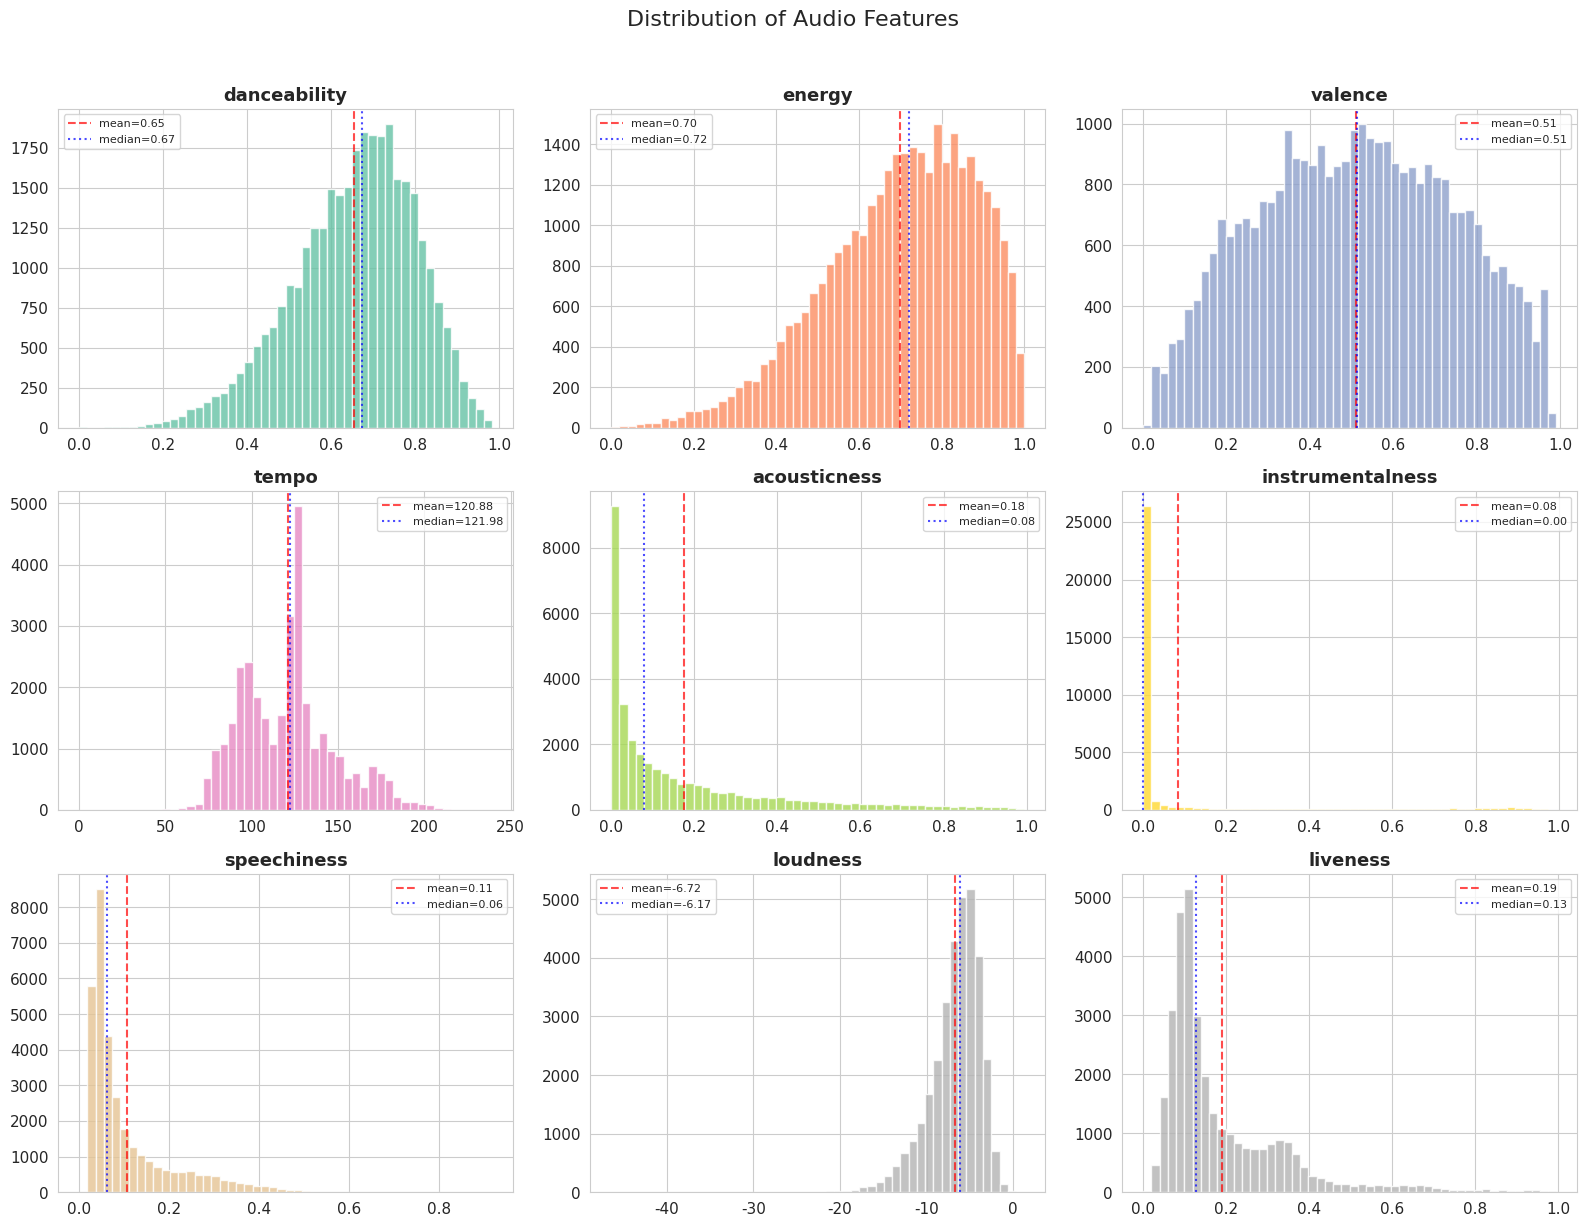

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
colors = plt.cm.Set2(np.linspace(0, 1, 9))

for idx, feat in enumerate(AUDIO_FEATURES):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[feat], bins=50, color=colors[idx], edgecolor='white', alpha=0.8)
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.axvline(df[feat].mean(), color='red', linestyle='--', alpha=0.7, label=f'mean={df[feat].mean():.2f}')
    ax.axvline(df[feat].median(), color='blue', linestyle=':', alpha=0.7, label=f'median={df[feat].median():.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Audio Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 2.2 피처별 박스플롯 (이상치 확인)

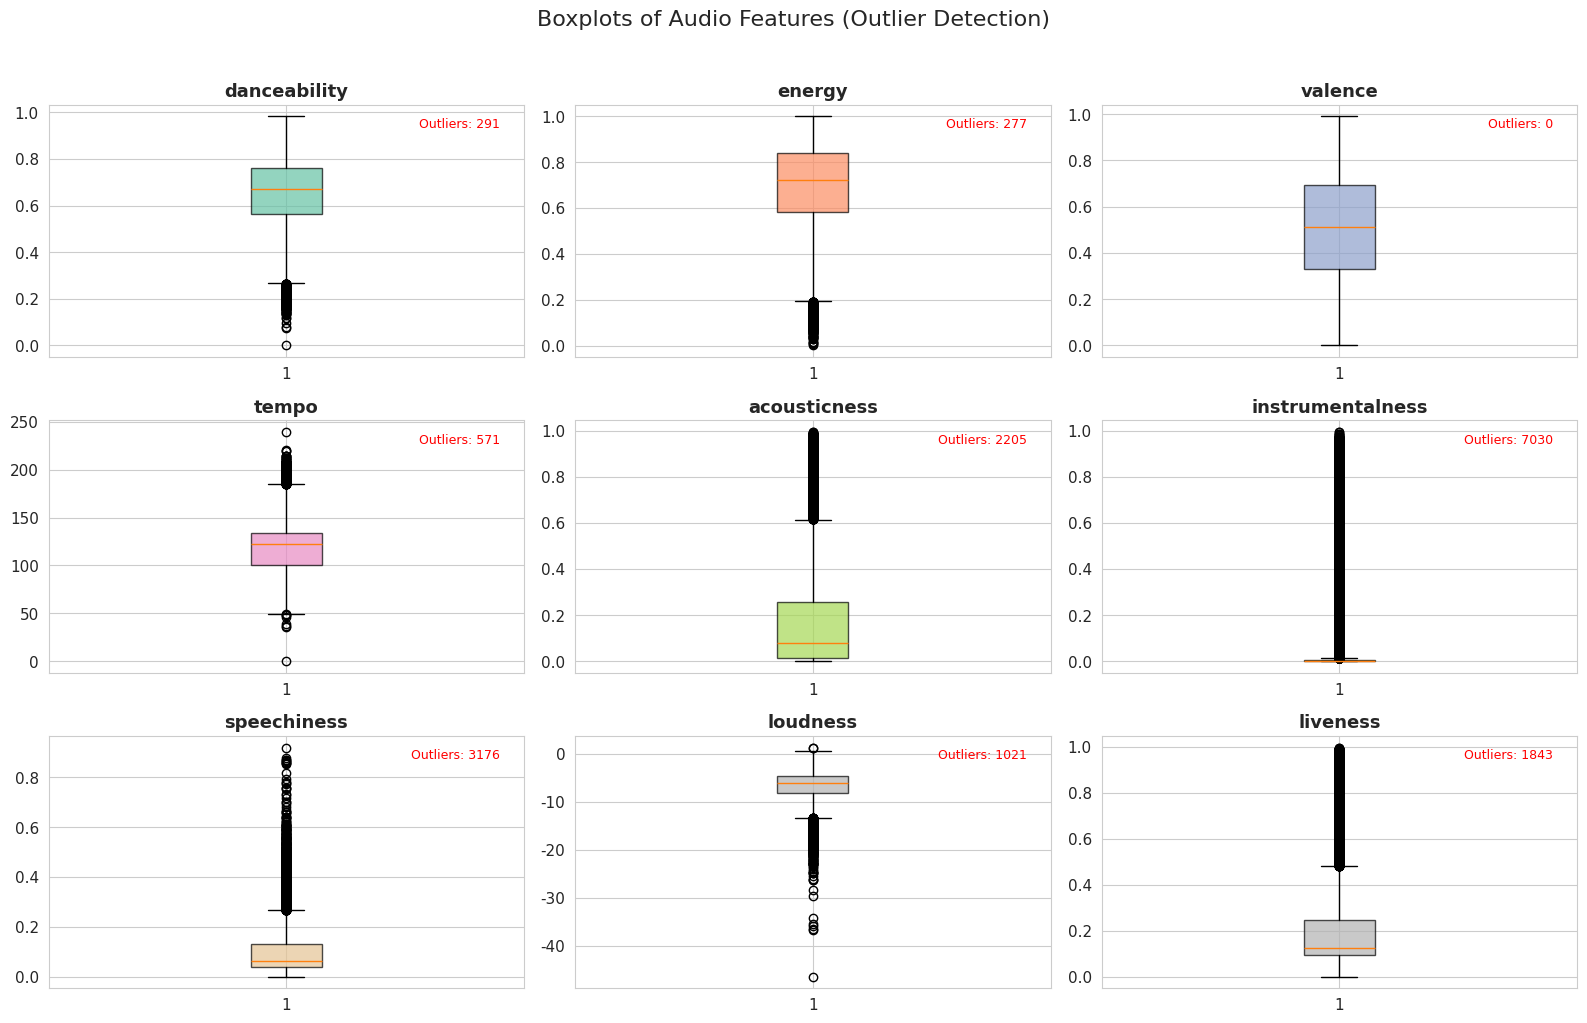

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for idx, feat in enumerate(AUDIO_FEATURES):
    ax = axes[idx // 3, idx % 3]
    bp = ax.boxplot(df[feat].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colors[idx], alpha=0.7))
    ax.set_title(feat, fontsize=13, fontweight='bold')
    
    # IQR 기준 이상치 수 표시
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[feat] < Q1 - 1.5 * IQR) | (df[feat] > Q3 + 1.5 * IQR)).sum()
    ax.text(0.95, 0.95, f'Outliers: {outliers}', transform=ax.transAxes, 
            ha='right', va='top', fontsize=9, color='red')

plt.suptitle('Boxplots of Audio Features (Outlier Detection)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 2.3 피처 간 상관관계 히트맵

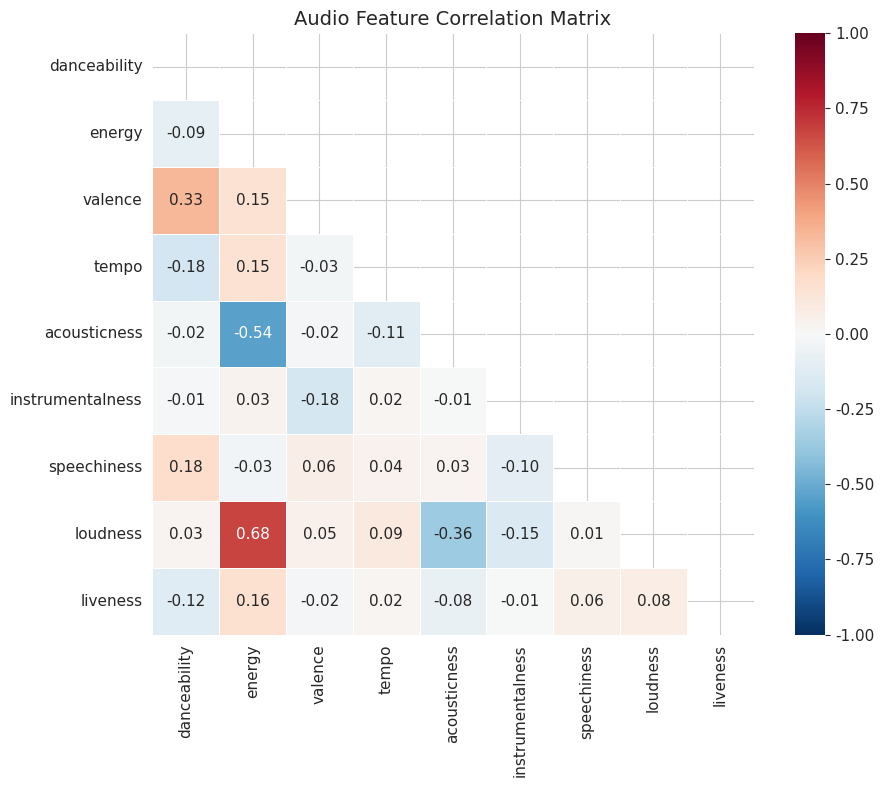

=== 상관계수 |r| > 0.3 인 피처 쌍 ===
  danceability ↔ valence: r = 0.331
  energy ↔ acousticness: r = -0.540
  energy ↔ loudness: r = 0.677
  acousticness ↔ loudness: r = -0.362


In [ ]:
corr = df[AUDIO_FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Audio Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# 강한 상관관계 쌍 추출
print("=== 상관계수 |r| > 0.3 인 피처 쌍 ===")
for i in range(len(AUDIO_FEATURES)):
    for j in range(i+1, len(AUDIO_FEATURES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.3:
            print(f"  {AUDIO_FEATURES[i]} ↔ {AUDIO_FEATURES[j]}: r = {r:.3f}")

## 2.4 주요 상관 쌍 산점도

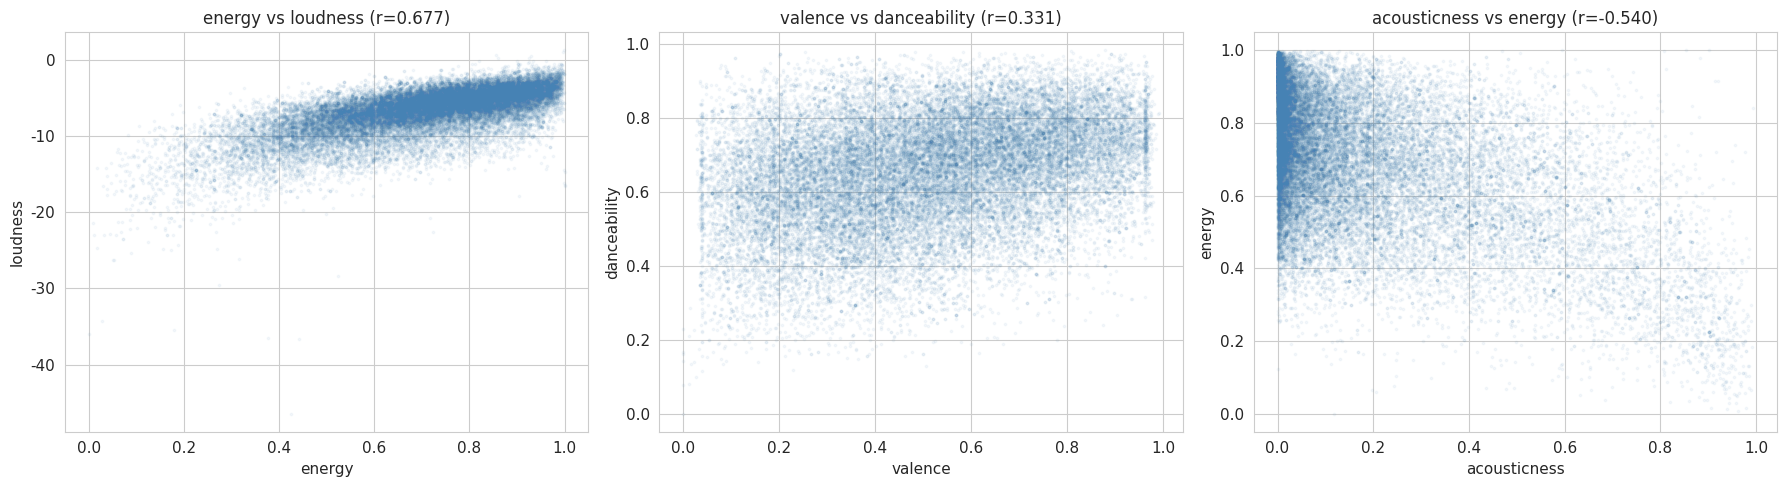

In [ ]:
pairs = [('energy', 'loudness'), ('valence', 'danceability'), ('acousticness', 'energy')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (x, y) in enumerate(pairs):
    ax = axes[idx]
    ax.scatter(df[x], df[y], alpha=0.05, s=3, color='steelblue')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    r = df[[x, y]].corr().iloc[0, 1]
    ax.set_title(f'{x} vs {y} (r={r:.3f})', fontsize=12)

plt.tight_layout()
plt.show()

## 2.5 Valence × Energy 감정 공간 (핵심)

MindTune의 감정 매핑에서 가장 중요한 두 축입니다.
- **Valence** (긍정도): 높을수록 행복/밝음, 낮을수록 슬픔/우울
- **Energy** (에너지): 높을수록 강렬/활기, 낮을수록 차분/고요

이 2D 공간에서 곡들이 어떻게 분포하는지가 감정 기반 추천의 품질을 결정합니다.

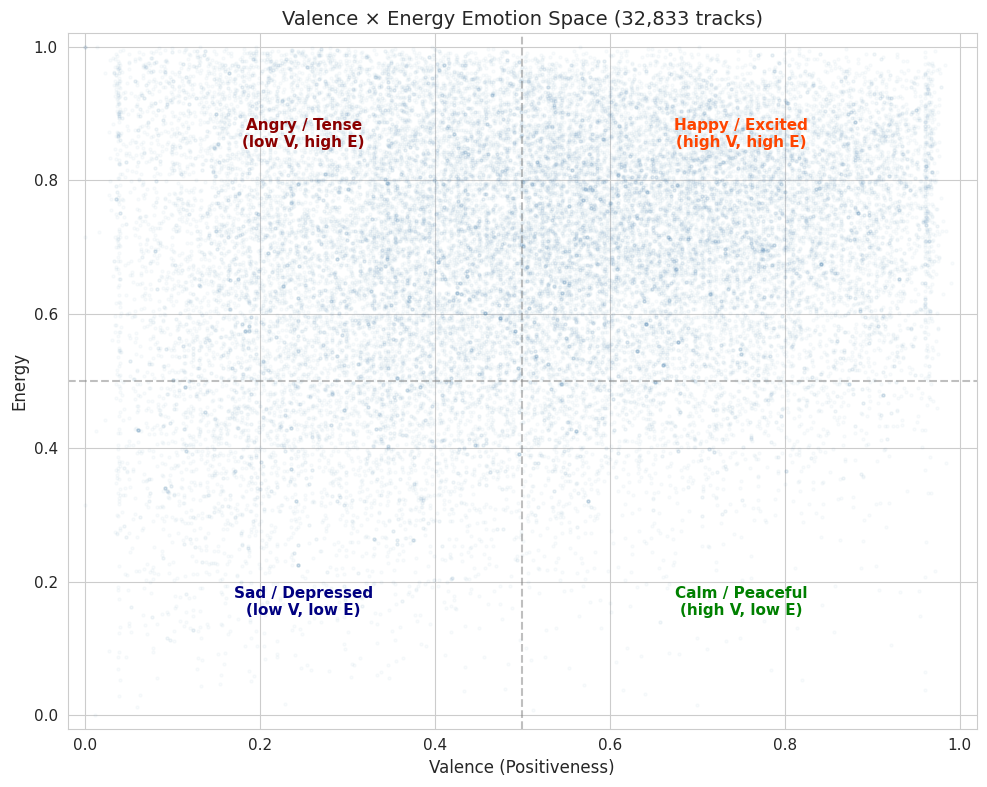

=== 감정 사분면별 곡 수 ===
  Happy/Excited (high V, high E): 15,382곡 (46.8%)
  Angry/Tense (low V, high E): 12,595곡 (38.4%)
  Calm/Peaceful (high V, low E): 1,664곡 (5.1%)
  Sad/Depressed (low V, low E): 3,189곡 (9.7%)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(df['valence'], df['energy'], alpha=0.03, s=5, c='steelblue')

# 감정 사분면 표시
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)

# 사분면 레이블
ax.text(0.75, 0.85, 'Happy / Excited\n(high V, high E)', ha='center', fontsize=11, color='orangered', fontweight='bold')
ax.text(0.25, 0.85, 'Angry / Tense\n(low V, high E)', ha='center', fontsize=11, color='darkred', fontweight='bold')
ax.text(0.75, 0.15, 'Calm / Peaceful\n(high V, low E)', ha='center', fontsize=11, color='green', fontweight='bold')
ax.text(0.25, 0.15, 'Sad / Depressed\n(low V, low E)', ha='center', fontsize=11, color='navy', fontweight='bold')

ax.set_xlabel('Valence (Positiveness)', fontsize=12)
ax.set_ylabel('Energy', fontsize=12)
ax.set_title('Valence × Energy Emotion Space (32,833 tracks)', fontsize=14)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()

# 사분면별 곡 수
print("=== 감정 사분면별 곡 수 ===")
for vl, vh, el, eh, label in [
    (0.5, 1, 0.5, 1, "Happy/Excited (high V, high E)"),
    (0, 0.5, 0.5, 1, "Angry/Tense (low V, high E)"),
    (0.5, 1, 0, 0.5, "Calm/Peaceful (high V, low E)"),
    (0, 0.5, 0, 0.5, "Sad/Depressed (low V, low E)")
]:
    count = len(df[(df['valence'] >= vl) & (df['valence'] < vh) & 
                   (df['energy'] >= el) & (df['energy'] < eh)])
    print(f"  {label}: {count:,}곡 ({count/len(df)*100:.1f}%)")

## 2.6 PCA 시각화 (9개 피처 → 2D)

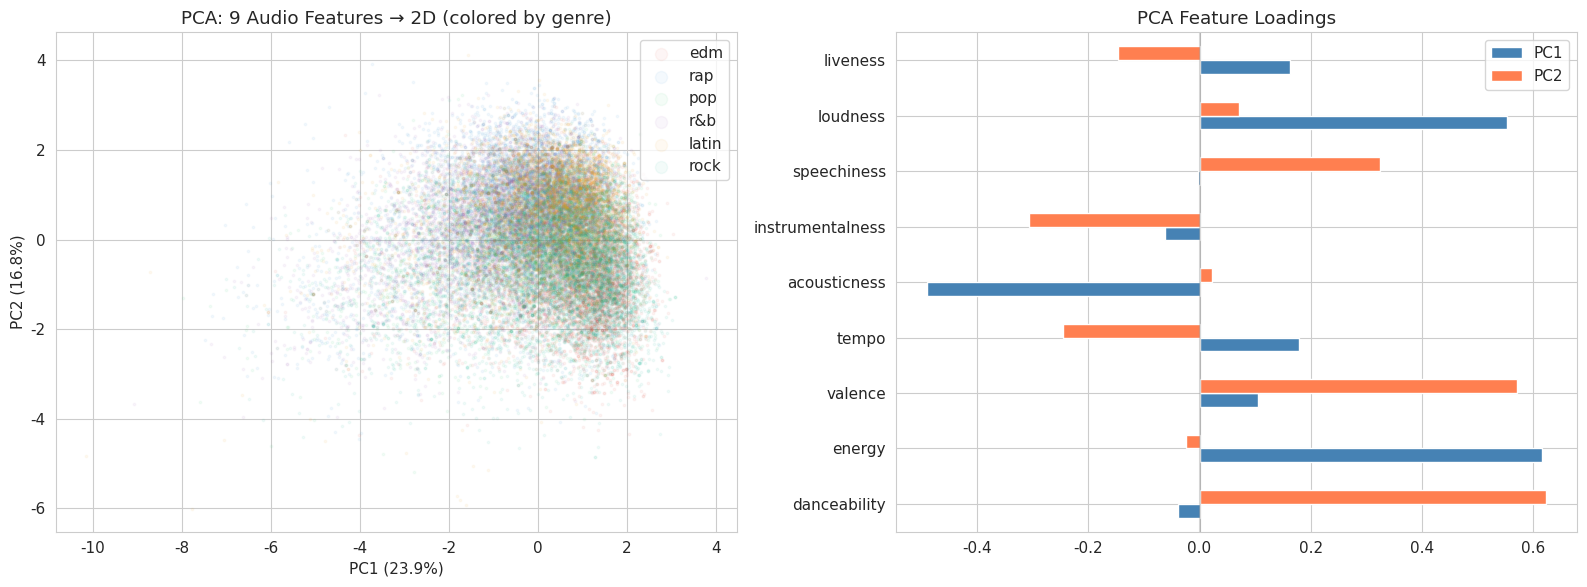

PC1 + PC2 설명 분산: 40.7%

=== 누적 설명 분산 ===
  PC1~PC1: 23.9%
  PC1~PC2: 40.7%
  PC1~PC3: 52.8%
  PC1~PC4: 63.7%
  PC1~PC5: 74.6%


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[AUDIO_FEATURES].fillna(0))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA 산점도 (장르 색상)
genre_colors = {'edm': '#e74c3c', 'rap': '#3498db', 'pop': '#2ecc71', 
                'r&b': '#9b59b6', 'latin': '#f39c12', 'rock': '#1abc9c'}
for genre, color in genre_colors.items():
    mask = df['playlist_genre'] == genre
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.05, s=3, 
                    color=color, label=genre)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA: 9 Audio Features → 2D (colored by genre)')
axes[0].legend(markerscale=5, loc='upper right')

# PCA 로딩 벡터 (어떤 피처가 각 축에 기여하는지)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=AUDIO_FEATURES)
loadings.plot(kind='barh', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('PCA Feature Loadings')
axes[1].axvline(0, color='gray', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PC1 + PC2 설명 분산: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# 전체 PCA 설명 분산
pca_full = PCA().fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
print(f"\n=== 누적 설명 분산 ===")
for i, cv in enumerate(cumvar[:5]):
    print(f"  PC1~PC{i+1}: {cv*100:.1f}%")

## 2.7 요약

**피처 분석 인사이트**:
- **강한 양의 상관**: energy ↔ loudness (큰 에너지 = 큰 볼륨)
- **강한 음의 상관**: acousticness ↔ energy (어쿠스틱 곡은 대체로 차분)
- **감정 공간**: valence × energy 2D 공간에서 사분면별 곡 수가 균등한지가 감정 추천 품질을 좌우
- **PCA**: 2개 주성분으로 전체 분산의 얼마를 설명하는지, 어떤 피처가 주요 축인지 확인
- **instrumentalness, speechiness**: 0 근처에 극단적으로 편중 (대부분 보컬 있는 곡) → 코딩/집중 음악 추천 시 후보 제한적일 수 있음